<a href="https://colab.research.google.com/github/deltorobarba/science/blob/main/astrophysics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color="blue">**Astrophysics 🔭**

![science](https://raw.githubusercontent.com/deltorobarba/science/main/science.JPG)

In [ ]:
#############################################
# Gravitational Wave Research
#############################################

!pip install -q gwpy gwosc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gwosc.api import fetch_allevents_json
from gwosc.datasets import event_gps, event_detectors
from gwpy.timeseries import TimeSeries

plt.rcParams["figure.figsize"] = (9, 4)
pd.set_option("display.max_columns", None)

In [ ]:
# 1. Connect to the GWOSC (Gravitational Wave Open Science Center) from on LIGO/Virgo/KAGRA & Fetch Events
catalog_raw = fetch_allevents_json()["events"]
print(f"{len(catalog_raw)} Records in the catalog (including multiple versions per event)")

rows = []
for key, meta in catalog_raw.items():
    rows.append({
        "dataset_key": key,
        "event": meta.get("commonName"),
        "version": meta.get("version"),
        "catalog": meta.get("catalog.shortName"),
        "gps": meta.get("GPS"),
        "mass_1_source": meta.get("mass_1_source"),
        "mass_2_source": meta.get("mass_2_source"),
        "chirp_mass_source": meta.get("chirp_mass_source"),
        "network_snr": meta.get("network_matched_filter_snr"),
        "distance_mpc": meta.get("luminosity_distance"),
    })

events_df = pd.DataFrame(rows)

# Retain only the latest data version per event
events_df = (
    events_df.sort_values("version")
              .drop_duplicates(subset="event", keep="last")
              .reset_index(drop=True)
)
print(f"{len(events_df)} unique events found")
#events_df.head()

print("✅ Filter Top-K Events by network SNR (statistically significant detection)")
K = 10
top_k = (
    events_df.dropna(subset=["network_snr"])
              .sort_values("network_snr", ascending=False)
              .head(K)
)
top_k[["event", "catalog", "network_snr", "mass_1_source", "mass_2_source", "distance_mpc"]]

671 Records in the catalog (including multiple versions per event)
433 unique events found
✅ Filter Top-K Events by network SNR (statistically significant detection)


,event,catalog,network_snr,mass_1_source,mass_2_source,distance_mpc
348,GW250114_082203,GWTC-5.0,78.60,33.76,32.26,405.0
242,GW250207_115645,O4_Discovery_Papers,68.91,35.20,30.60,187.0
404,GW230814_230901,GWTC-4.1,43.00,33.70,28.20,290.0
69,GW240920_124024,GWTC-5.0,37.40,37.10,31.90,1090.0
355,GW241011_233834,GWTC-5.0,35.80,19.50,5.96,212.0
381,GW231226_101520,GWTC-4.1,34.70,40.20,35.10,1180.0
424,GW170817,GWTC-1-confident,33.00,1.46,1.27,40.0
238,GW241127_061008,GWTC-5.0,31.30,63.80,20.80,1080.0
356,GW240925_005809,GWTC-5.0,31.20,9.02,6.99,356.0
260,GW230627_015337,GWTC-4.1,28.70,8.40,5.74,305.0


In [ ]:
# 2. Select specific event (GW150914 for first detection in 2015, or GW170817 for neutron star merger)

SELECTED_EVENT = "GW150914"  # <- Enter event names from table above

info = events_df.loc[events_df["event"] == SELECTED_EVENT].iloc[0]
gps = event_gps(SELECTED_EVENT)
detectors = sorted(event_detectors(SELECTED_EVENT))
DETECTOR = detectors[0]  # Select a different detector from the list if necessary.

print(f"Event:          {SELECTED_EVENT}")
print(f"GPS time:        {gps}")
print(f"Detector:      {detectors}  -> use '{DETECTOR}'")
print(f"Mass (M_sun):  {info['mass_1_source']:.1f} + {info['mass_2_source']:.1f}")
print(f"Network-SNR:    {info['network_snr']:.1f}")
print(f"Distance:      {info['distance_mpc']:.0f} Mpc")

Event:          GW150914
GPS time:        1126259462.4
Detector:      ['H1', 'L1']  -> use 'H1'
Mass (M_sun):  34.6 + 30.0
Network-SNR:    26.0
Distance:      470 Mpc


Detector: H1. Duration: 32.0 s. Sample rate: 4096.0 Hz. Values: 131072



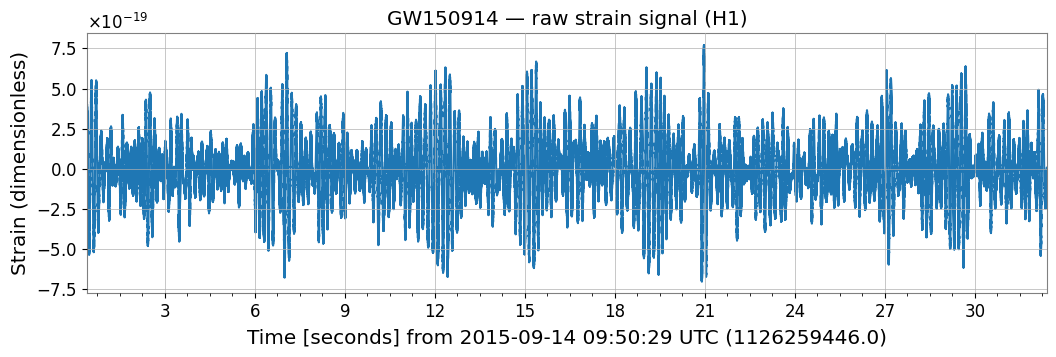

In [ ]:
# 3. Load strain data & initial numerical visualization

"""
TimeSeries.fetch_open_data() loads the raw strain time series from the selected detector around the time of the merger.
Before moving on to the Q-transform, we examine the raw data both numerically (using key metrics) and via a time-series
plot—at this stage, the signal is still completely buried in the detector noise.
"""

PADDING = 16  # Seconds of raw data before/after the event

start, end = gps - PADDING, gps + PADDING
strain = TimeSeries.fetch_open_data(DETECTOR, start, end, sample_rate=4096, cache=True)

print(f"Detector: {DETECTOR}. Duration: {strain.duration}. Sample rate: {strain.sample_rate}. Values: {len(strain)}\n")

# Numerical metrics of the raw strain signal
#strain_stats = pd.Series(strain.value, name="strain").describe()
#display(strain_stats)

# Time-series plot (signal is still hidden in the noise here)
plot = strain.plot()
ax = plot.gca()
ax.set_ylabel("Strain (dimensionless)")
ax.set_title(f"{SELECTED_EVENT} — raw strain signal ({DETECTOR})")
plot.show()

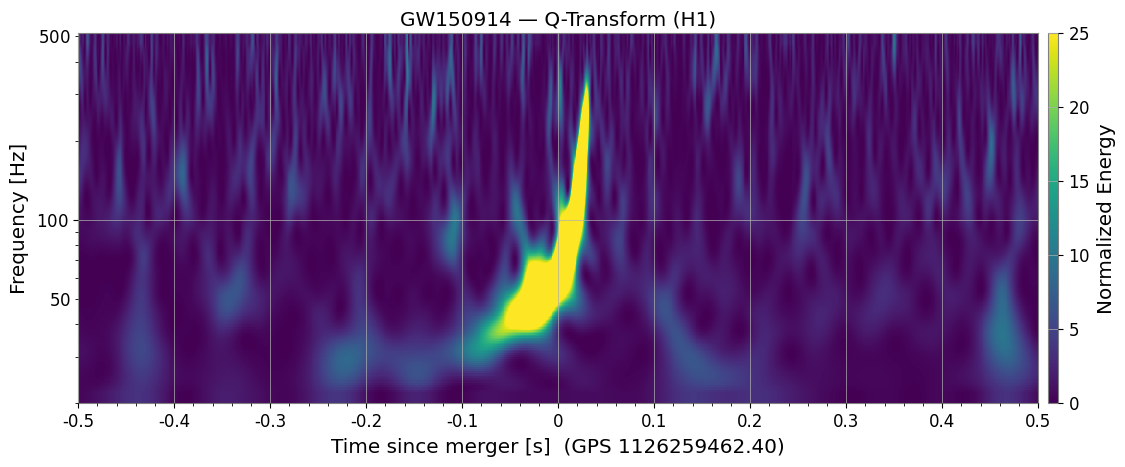

In [ ]:
# 4. Q-Transform to make the chirp visible

"""
* Q-Transform is a wavelet-like time-frequency decomposition featuring
logarithmically spaced frequency bins and a constant quality factor
`Q = f / Δf` (as opposed to the fixed window width used in the STFT). This
allows for equally good resolution of short, high-frequency events and
longer-duration, low-frequency ones—making it ideal for an inspiral
"chirp" signal, where the frequency increases over time.

Beforehand, the signal is whitened (`whiten()`) to remove the detector's
frequency-dependent noise profile (seismic noise at low frequencies,
quantum noise at high frequencies)—only then does the transient signal
stand out clearly in the spectrogram.

The rising arc (frequency increasing over time) represents the
characteristic **chirp** of the inspiral just before the merger. To
experiment further: enter a different `SELECTED_EVENT` or `DETECTOR` in
Step 3 and re-run the cells, or adjust `QRANGE`/`FRANGE` in Step 5 to
modify the resolution or frequency window.
"""

QRANGE = (4, 64)      # Q-Range of transform
FRANGE = (20, 512)    # Frequency range in Hz
WINDOW = 0.5          # Seconds around the merger that are being plotted

white_strain = strain.whiten()
qspec = white_strain.q_transform(
    qrange=QRANGE,
    frange=FRANGE,
    outseg=(gps - WINDOW, gps + WINDOW),
)

plot = qspec.plot(figsize=(12, 5))
ax = plot.gca()
ax.set_xscale("seconds", epoch=gps)
ax.set_yscale("log")
ax.set_ylim(*FRANGE)
ax.set_ylabel("Frequency [Hz]")
ax.set_xlabel(f"Time since merger [s]  (GPS {gps:.2f})")
ax.set_title(f"{SELECTED_EVENT} — Q-Transform ({DETECTOR})")
ax.colorbar(label="Normalized Energy", clim=(0, 25))
plot.show()

In [ ]:
#############################################
# Exoplanet Research
#############################################

!pip install -q lightkurve astroquery
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lightkurve as lk
from astropy import units as u
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive

plt.rcParams["figure.figsize"] = (9, 4)
pd.set_option("display.max_columns", None)

In [ ]:
# 1. Load Catalogue Data
# Goal: Calculate Transit-Period of confirmed Exoplanets from Kepler/TESS raw data
COLUMNS = ("pl_name, hostname, disc_year, discoverymethod, disc_facility, "
           "pl_orbper, pl_rade, pl_bmasse, sy_dist, st_teff, st_rad")

catalog_raw = NasaExoplanetArchive.query_criteria(table="pscomppars", select=COLUMNS)
print(f" ✅ {len(catalog_raw)} confirmed exoplanets in the archive")

planets_df = catalog_raw.to_pandas()
planets_df["dist_ly"] = planets_df["sy_dist"] * 3.26156   # parsec -> light-year

# One row per planet name, transit candidates first
planets_df = planets_df.drop_duplicates(subset="pl_name", keep="first").reset_index(drop=True)
display(planets_df.head())

# Get overview of methods und nächstgelegene Transit-Planeten
print("\n ✅ Discovery methods in the catalog")
display(planets_df["discoverymethod"].value_counts().head(8))

print("\n ✅ Top-K nearest planets discovered by the Transit method")
K = 10
top_k = (
    planets_df[(planets_df["discoverymethod"] == "Transit") & planets_df["pl_orbper"].notna()]
    .dropna(subset=["dist_ly"])
    .sort_values("dist_ly")
    .head(K)
)
top_k[["pl_name", "hostname", "disc_year", "pl_orbper", "pl_rade", "dist_ly"]]

 ✅ 6360 confirmed exoplanets in the archive


,pl_name,hostname,disc_year,discoverymethod,disc_facility,pl_orbper,pl_rade,pl_bmasse,sy_dist,st_teff,st_rad,dist_ly
0,HD 2039 b,HD 2039,2002,Radial Velocity,Anglo-Australian Telescope,1120.000000,12.700000,1999.1507,85.6922,5945.0,1.190,279.490252
1,HAT-P-8 b,HAT-P-8,2008,Transit,HATNet,3.076340,15.692600,406.8224,211.5530,6200.0,1.570,689.992803
2,K2-43 b,K2-43,2016,Transit,K2,3.471149,4.510000,18.5000,182.5360,3840.6,0.542,595.352116
3,Kepler-1753 b,Kepler-1753,2021,Transit,Kepler,16.004601,2.226781,5.5900,707.6880,5180.0,0.769,2308.166873
4,Kepler-1176 b,Kepler-1176,2016,Transit,Kepler,24.173858,2.450000,6.5700,864.6990,5844.0,1.020,2820.267670



 ✅ Discovery methods in the catalog


,count
discoverymethod,
Transit,4706
Radial Velocity,1200
Microlensing,285
Imaging,97
Transit Timing Variations,29
Eclipse Timing Variations,17
Orbital Brightness Modulation,9
Pulsar Timing,8



 ✅ Top-K nearest planets discovered by the Transit method


,pl_name,hostname,disc_year,pl_orbper,pl_rade,dist_ly
402,LTT 1445 A c,LTT 1445 A,2022,3.123903,1.147,22.404601
329,LTT 1445 A b,LTT 1445 A,2019,5.358764,1.340,22.404601
399,GJ 367 b,GJ 367,2021,0.321923,0.736,30.699858
326,GJ 357 b,GJ 357,2019,3.930600,1.200,30.795030
349,AU Mic b,AU Mic,2020,8.463446,4.790,31.709212
392,AU Mic c,AU Mic,2021,18.859023,2.790,31.709212
415,HD 260655 b,HD 260655,2022,2.769530,1.240,32.633539
416,HD 260655 c,HD 260655,2022,5.705880,1.533,32.633539
171,GJ 341 b,GJ 341,2025,7.576860,0.880,34.096348
319,L 98-59 c,L 98-59,2019,3.690676,1.329,34.635810


In [ ]:
# 2. Select exoplanet, get details and check for available pixelfile data
SELECTED_PLANET = "Kepler-8 b"   # <- Enter a planet name from the table above

match = planets_df.loc[planets_df["pl_name"] == SELECTED_PLANET]
if len(match) == 0:
    raise ValueError(f"'{SELECTED_PLANET}' not found. Check the spelling (note the space before 'b').")
info = match.iloc[0]

print(f"✅ Exoplanet:      {info['pl_name']}")
print(f"Host star:         {info['hostname']}")
print(f"Discovery:         {info['disc_year']}  |  {info['discoverymethod']}  |  {info['disc_facility']}")
print(f"Distance:          {info['dist_ly']:,.0f} light-years  ({info['sy_dist']:.1f} pc)")
print(f"Star temperature:  {info['st_teff']:.0f} K")
print(f"Star radius:       {info['st_rad']:.2f} R_sun")
print(f"Planet radius:     {info['pl_rade']:.2f} R_earth")
print(f"Planet mass:       {info['pl_bmasse']:.2f} M_earth")
print(f"Orbital period:    {info['pl_orbper']:.4f} days   <- catalog value, we recalculate later")

# Check for available pixelfile data
search = lk.search_targetpixelfile(SELECTED_PLANET)
if len(search) == 0:
    raise RuntimeError(f"No pixel files found for '{SELECTED_PLANET}'.")

avail = search.table.to_pandas()
cols = [c for c in ["mission", "author", "t_exptime", "year", "distance"] if c in avail.columns]
avail = avail[cols].rename(columns={"t_exptime": "exptime_s"})

print(f"{len(search)} target pixel files available\n")
display(avail.groupby(["author", "exptime_s"]).size().rename("n_files").reset_index())
avail.head(10)

✅ Exoplanet:      Kepler-8 b
Host star:         Kepler-8
Discovery:         2010  |  Transit  |  Kepler
Distance:          3,333 light-years  (1021.9 pc)
Star temperature:  6213 K
Star radius:       1.49 R_sun
Planet radius:     15.87 R_earth
Planet mass:       187.52 M_earth
Orbital period:    3.5225 days   <- catalog value, we re-derive this in step 6
63 target pixel files available



,author,exptime_s,n_files
0,Kepler,60.0,31
1,Kepler,1800.0,18
2,SPOC,120.0,7
3,TESS-SPOC,200.0,3
4,TESS-SPOC,600.0,4


,mission,author,exptime_s,year,distance
0,Kepler Quarter 02,Kepler,60.0,2009,0.0
1,Kepler Quarter 02,Kepler,60.0,2009,0.0
2,Kepler Quarter 02,Kepler,60.0,2009,0.0
3,Kepler Quarter 03,Kepler,60.0,2009,0.0
4,Kepler Quarter 03,Kepler,60.0,2009,0.0
5,Kepler Quarter 03,Kepler,60.0,2009,0.0
6,Kepler Quarter 00,Kepler,1800.0,2009,0.0
7,Kepler Quarter 01,Kepler,1800.0,2009,0.0
8,Kepler Quarter 02,Kepler,1800.0,2009,0.0
9,Kepler Quarter 03,Kepler,1800.0,2009,0.0


✅ Selected: author=Kepler, exptime=1800s, mission=Kepler Quarter 01
✅ Downloading target pixel file (30-60 s for large Kepler quarters)...
   Shape (cadences, rows, cols): (1626, 6, 6)
   Cadences: 1626   |   Baseline: 33.5 days


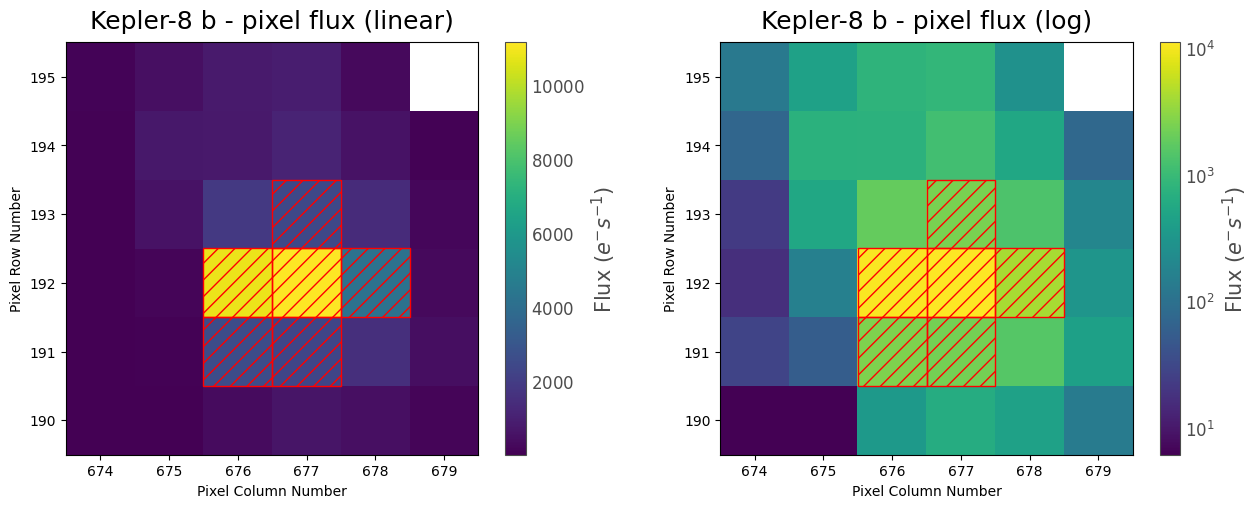

In [ ]:
# 3. Load and Visualize Target Pixel File
AUTHOR_PRIORITY = ["Kepler", "K2", "SPOC", "TESS-SPOC", "QLP"]
PREFER_SHORT_CADENCE = False

authors_present = list(dict.fromkeys(avail["author"].tolist()))
chosen_author = next((a for a in AUTHOR_PRIORITY if a in authors_present), authors_present[0])

subset = avail[avail["author"] == chosen_author].sort_values(
    "exptime_s", ascending=PREFER_SHORT_CADENCE
)
row = subset.iloc[0]
idx = int(subset.index[0])

print(f"✅ Selected: author={chosen_author}, exptime={row['exptime_s']:.0f}s, mission={row['mission']}")
print(f"✅ Downloading target pixel file (30-60 s for large Kepler quarters)...")
tpf = search[idx].download(quality_bitmask="default")

print(f"   Shape (cadences, rows, cols): {tpf.shape}")
print(f"   Cadences: {len(tpf.time)}   |   Baseline: {(tpf.time[-1] - tpf.time[0]).value:.1f} days")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
tpf.plot(ax=axes[0], aperture_mask=tpf.pipeline_mask,
         title=f"{SELECTED_PLANET} - pixel flux (linear)")
tpf.plot(ax=axes[1], aperture_mask=tpf.pipeline_mask, scale="log",
         title=f"{SELECTED_PLANET} - pixel flux (log)")
fig.tight_layout()
plt.show()


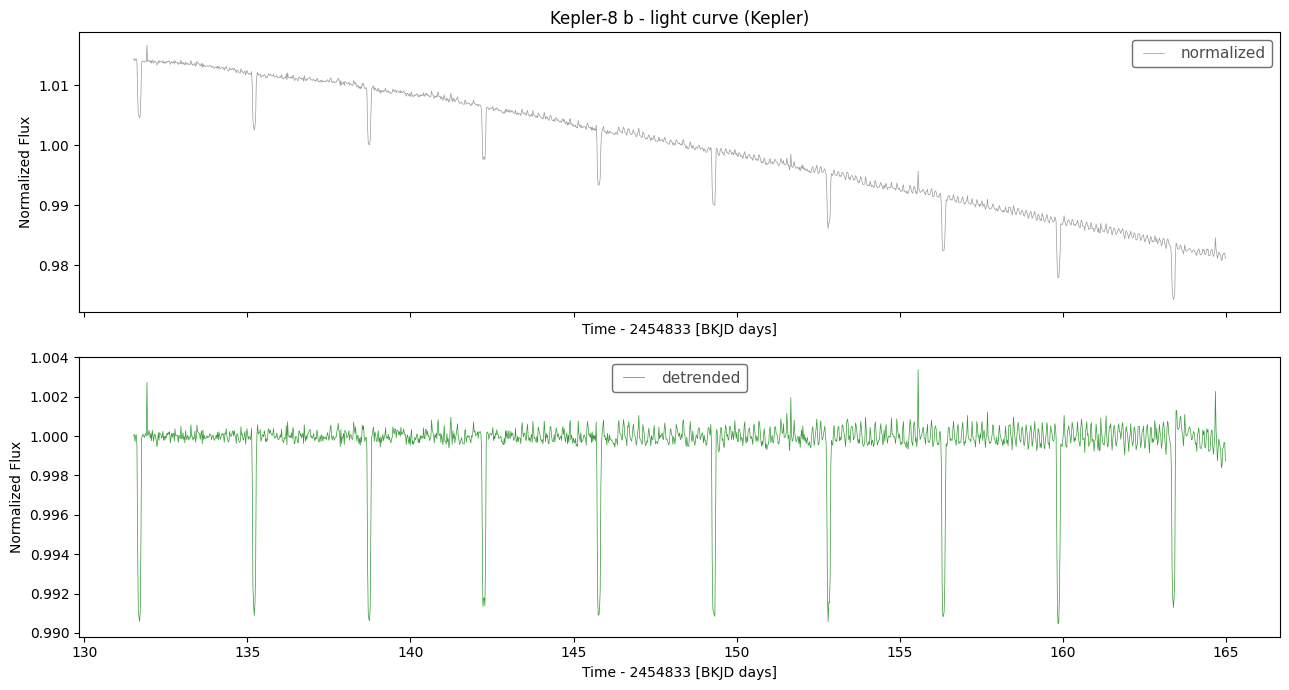

In [ ]:
# 4. Extract Lightcurve and detrend
lc_raw = tpf.to_lightcurve(aperture_mask=tpf.pipeline_mask)
lc = lc_raw.remove_nans().remove_outliers(sigma=5).normalize()
lc_flat = lc.flatten(window_length=101)   # must be >> transit duration, << orbital period

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
lc.plot(ax=axes[0], c="grey", alpha=0.8, label="normalized")
axes[0].set_title(f"{SELECTED_PLANET} - light curve ({chosen_author})")
lc_flat.plot(ax=axes[1], c="green", alpha=0.8, label="detrended")
fig.tight_layout()
plt.show()

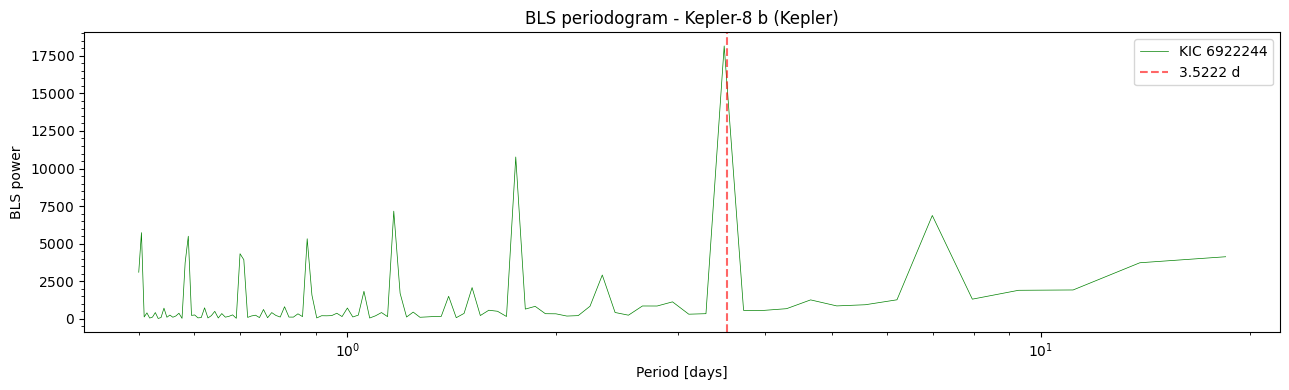

✅ Computing BLS periodogram (coarse pass, ~30-60 s)
  Coarse peak:     3.4940 days
✅ Refining around the peak:
  Orbital period:  3.52217 days  =  84.53 hours
  Transit epoch:   131.6890
  Duration:        2.69 hours
  Depth:           7960 ppm  ->  Rp/Rs = 0.0892
  NASA catalog:    3.52250 days
  Deviation:       0.009 %


In [ ]:
# 5. Compute BLS-Periodogramm
# NOTE: minimum_period / maximum_period / period / duration must be PLAIN FLOATS in days.
# lightkurve computes the frequency grid spacing from the unitless lc.time.value, so passing
# astropy Quantities here raises "only dimensionless scalar quantities can be converted".

# Coarse pass peak calculation
DURATIONS = np.linspace(0.04, 0.30, 12)   # trial transit durations [days]

pg_coarse = lc_flat.to_periodogram(
    method="bls",
    minimum_period=0.5,
    maximum_period=20.0,
    duration=DURATIONS,
    frequency_factor=500,
)
p_coarse = pg_coarse.period_at_max_power          # <- comes back WITH units

# Refine on a narrow grid around the coarse peak (plain float array, again no units)
period_grid = np.linspace(0.98 * p_coarse.value, 1.02 * p_coarse.value, 4000)
pg = lc_flat.to_periodogram(method="bls", period=period_grid, duration=DURATIONS)

period   = pg.period_at_max_power
t0       = pg.transit_time_at_max_power
duration = pg.duration_at_max_power
depth    = float(pg.depth_at_max_power)

fig, ax = plt.subplots(figsize=(13, 4))
pg_coarse.plot(ax=ax, color="green")
ax.axvline(period.value, color="red", ls="--", alpha=0.6, label=f"{period.value:.4f} d")
ax.set_xscale("log")
ax.set_title(f"BLS periodogram - {SELECTED_PLANET} ({chosen_author})")
ax.set_xlabel("Period [days]")
ax.set_ylabel("BLS power")
ax.legend()
fig.tight_layout()
plt.show()

# Print results
print(f"✅ Computing BLS periodogram (coarse pass, ~30-60 s)")
print(f"  Coarse peak:     {p_coarse.value:.4f} days")
print("✅ Refining around the peak:")
print(f"  Orbital period:  {period.value:.5f} days  =  {period.value * 24:.2f} hours")
print(f"  Transit epoch:   {t0.value:.4f}")
print(f"  Duration:        {duration.value * 24:.2f} hours")
print(f"  Depth:           {depth * 1e6:.0f} ppm  ->  Rp/Rs = {np.sqrt(depth):.4f}")
print(f"  NASA catalog:    {info['pl_orbper']:.5f} days")
print(f"  Deviation:       {abs(period.value - info['pl_orbper']) / info['pl_orbper'] * 100:.3f} %")

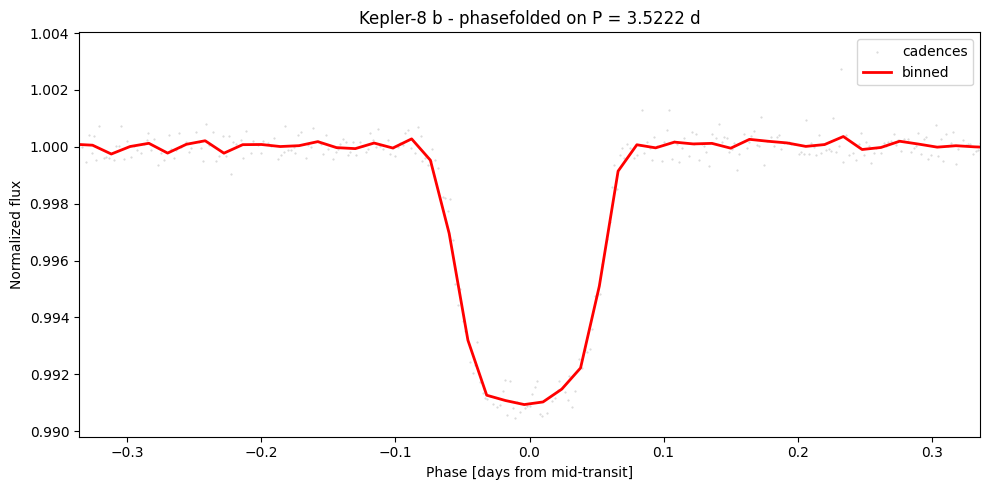

In [ ]:
# 6. Phase-folded Lightcurve
folded = lc_flat.fold(period=period, epoch_time=t0)
fig, ax = plt.subplots(figsize=(10, 5))
folded.scatter(ax=ax, c="lightgrey", s=1, label="cadences")
folded.bin(time_bin_size=duration / 8).plot(ax=ax, c="red", lw=2, label="binned")
ax.set_xlim(-3 * duration.value, 3 * duration.value)
ax.set_xlabel("Phase [days from mid-transit]")
ax.set_ylabel("Normalized flux")
ax.set_title(f"{SELECTED_PLANET} - phasefolded on P = {period.value:.4f} d")
ax.legend()
fig.tight_layout()
plt.show()